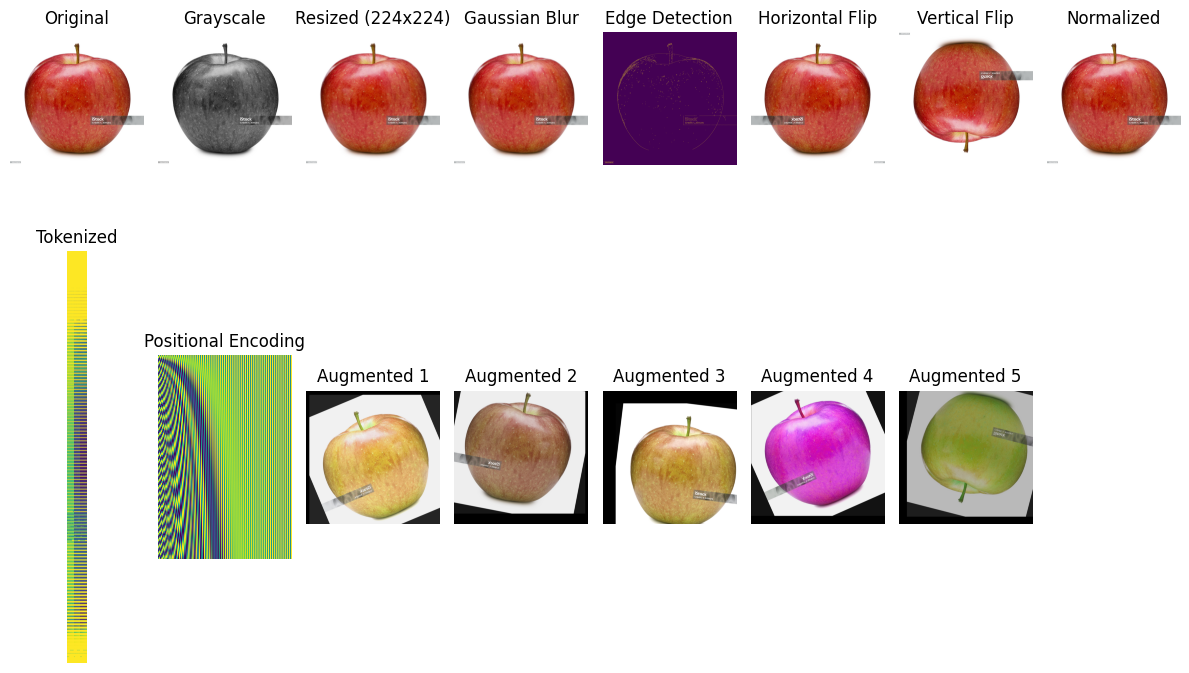

Swin Transformer Input Shape: torch.Size([3, 2048, 2048])
Tokenized Shape: torch.Size([1, 16384, 768])


In [3]:
import cv2
import numpy as np
import torch
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
from PIL import Image, ImageFilter
import os

# Load image
def load_image(image_path):
    image = Image.open(image_path).convert("RGB")
    return image

# Preprocessing Techniques
def apply_preprocessing(image, num_augments=5):
    aug_transforms = transforms.Compose([
        transforms.RandomRotation(30),
        transforms.RandomHorizontalFlip(),
        transforms.RandomVerticalFlip(),
        transforms.ColorJitter(brightness=0.5, contrast=0.5, saturation=0.5, hue=0.2),
        transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    ])

    transformations = {
        "Original": image,
        "Grayscale": image.convert("L"),
        "Resized (224x224)": image.resize((224, 224)),
        "Gaussian Blur": image.filter(ImageFilter.GaussianBlur(3)),
        "Edge Detection": Image.fromarray(cv2.Canny(np.array(image), 100, 200)),
        "Horizontal Flip": image.transpose(Image.FLIP_LEFT_RIGHT),
        "Vertical Flip": image.transpose(Image.FLIP_TOP_BOTTOM),
        "Normalized": transforms.ToTensor()(image),
        "Tokenized": tokenize_image(image),
        "Positional Encoding": positional_encoding(),
    }

    for i in range(num_augments):
        transformations[f"Augmented {i+1}"] = aug_transforms(image)

    return transformations

# Positional Encoding
def positional_encoding(image_size=224, patch_size=16):
    num_patches = (image_size // patch_size) ** 2
    position = torch.arange(num_patches).unsqueeze(1)
    div_term = torch.exp(torch.arange(0, 128, 2) * -(np.log(10000.0) / 128))
    pe = torch.zeros(1, num_patches, 128)
    pe[:, :, 0::2] = torch.sin(position * div_term)
    pe[:, :, 1::2] = torch.cos(position * div_term)
    return pe

# Tokenization (Flatten patches)
def tokenize_image(image, patch_size=16):
    image = transforms.ToTensor()(image).unsqueeze(0)
    _, C, H, W = image.shape
    patches = image.unfold(2, patch_size, patch_size).unfold(3, patch_size, patch_size)
    patches = patches.permute(0, 2, 3, 1, 4, 5).contiguous()
    patches = patches.view(1, -1, C * patch_size * patch_size)
    return patches

# Display images
def display_images(transformations):
    plt.figure(figsize=(12, 8))
    total_images = len(transformations)
    for i, (title, img) in enumerate(transformations.items()):
        plt.subplot(2, total_images // 2 + 1, i + 1)
        plt.imshow(img if isinstance(img, Image.Image) else torch.permute(img, (1, 2, 0)).numpy(), cmap='gray' if title == "Grayscale" else None)
        plt.title(title)
        plt.axis("off")
    plt.tight_layout()
    plt.show()

# Load and process an example image
image_path = "/content/apple.jpg"  # Change to your image path
image = load_image(image_path)
processed_images = apply_preprocessing(image, 5)
display_images(processed_images)

# Convert to tensor for Swin Transformer input
normalized_image = transforms.ToTensor()(image)
patches = tokenize_image(image)
pos_encoding = positional_encoding()

print("Swin Transformer Input Shape:", normalized_image.shape)
print("Tokenized Shape:", patches.shape)
